# Simulation-Based Inference for an Adaptive-Network Epidemic Model

**ST3247 Project — Sections 1–3 (Basic ABC + Summary Statistics)**

Sections covered here:
1. Data exploration
2. Summary statistics design & sensitivity analysis
3. Rejection ABC on pseudo-observed and real data
4. Posterior visualisations & posterior predictive check

Section 4 (Advanced methods: SMC-ABC, regression adjustment) lives in a separate notebook.

## 0. Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, gaussian_kde

from simulator import simulate         

rng_global = np.random.default_rng(42)

# Seaborn theme — matches the Epydemix tutorial aesthetic
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
PALETTE = sns.color_palette("Dark2")


## 1. Observed Data

We have $R = 40$ independent realisations of the epidemic, all generated with the same unknown
$(\beta, \gamma, \rho)$. Three data sources are available:

| File | What it contains |
|------|-----------------|
| `infected_timeseries.csv` | Fraction infected at each of $T=200$ steps, per replicate |
| `rewiring_timeseries.csv` | Number of rewiring events per step, per replicate |
| `final_degree_histograms.csv` | Degree distribution at $t=T$, per replicate |

We plot **all 40 replicate curves** at low opacity, then overlay the median and 10th–90th
percentile band.  Using percentiles (rather than mean ± SD) is more robust because epidemic
trajectories are right-skewed: a few slow-burn replicates can inflate the SD without changing
the typical behaviour.

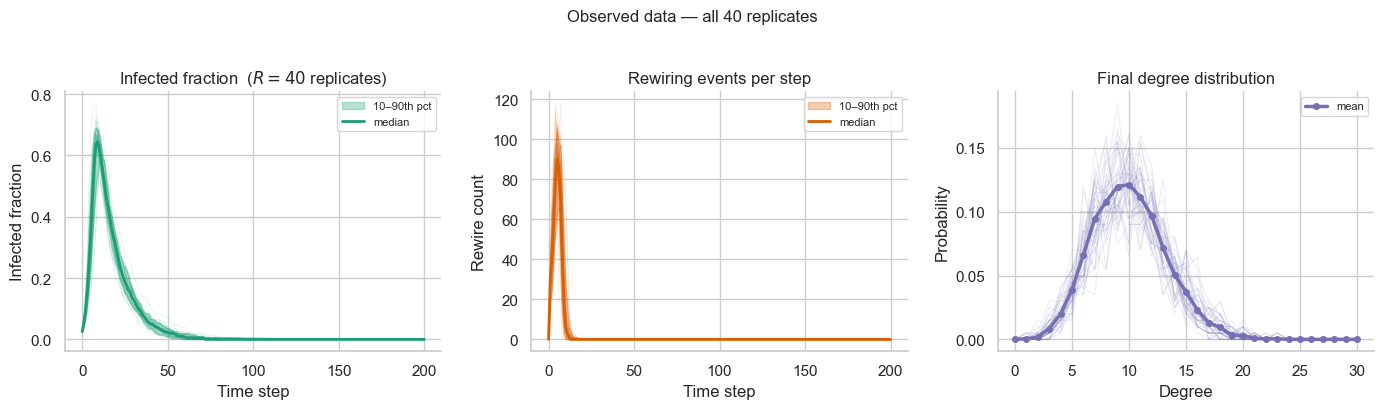

In [48]:
infected_obs = pd.read_csv("data/infected_timeseries.csv")
rewire_obs   = pd.read_csv("data/rewiring_timeseries.csv")
degree_obs   = pd.read_csv("data/final_degree_histograms.csv")

# ── pivot to (time x replicate) matrices ──────────────────────────────────────
inf_wide = infected_obs.pivot(index="time", columns="replicate_id", values="infected_fraction")
rew_wide = rewire_obs.pivot(  index="time", columns="replicate_id", values="rewire_count")

t = inf_wide.index.values

# percentile summaries
def pct_summary(wide):
    return (wide.quantile(0.10, axis=1),
            wide.quantile(0.50, axis=1),
            wide.quantile(0.90, axis=1))

inf_lo, inf_med, inf_hi = pct_summary(inf_wide)
rew_lo, rew_med, rew_hi = pct_summary(rew_wide)

# mean degree histogram across replicates
deg_mean = (degree_obs.groupby("degree")["count"]
                       .mean()
                       .reindex(range(31), fill_value=0))

# ── figure: 3 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1 — Infected fraction: individual traces + percentile envelope
ax = axes[0]
for col in inf_wide.columns:
    ax.plot(t, inf_wide[col].values, color=PALETTE[0], alpha=0.12, lw=0.6)
ax.fill_between(t, inf_lo, inf_hi, color=PALETTE[0], alpha=0.30, label="10–90th pct")
ax.plot(t, inf_med, color=PALETTE[0], lw=2.0, label="median")
ax.set(xlabel="Time step", ylabel="Infected fraction", title="Infected fraction  ($R=40$ replicates)")
ax.legend(fontsize=8)

# Panel 2 — Rewiring: individual traces + percentile envelope
ax = axes[1]
for col in rew_wide.columns:
    ax.plot(t, rew_wide[col].values, color=PALETTE[1], alpha=0.12, lw=0.6)
ax.fill_between(t, rew_lo, rew_hi, color=PALETTE[1], alpha=0.30, label="10–90th pct")
ax.plot(t, rew_med, color=PALETTE[1], lw=2.0, label="median")
ax.set(xlabel="Time step", ylabel="Rewire count", title="Rewiring events per step")
ax.legend(fontsize=8)

# Panel 3 — Final degree distribution: per-replicate histograms + mean
ax = axes[2]
for rep_id in degree_obs["replicate_id"].unique():
    d = (degree_obs[degree_obs["replicate_id"] == rep_id]
         .set_index("degree")["count"]
         .reindex(range(31), fill_value=0))
    ax.plot(d.index, d.values / d.sum(), color=PALETTE[2], alpha=0.12, lw=0.8)
obs_deg_prob = deg_mean / deg_mean.sum()
ax.plot(obs_deg_prob.index, obs_deg_prob.values, color=PALETTE[2], lw=2.5,
        marker="o", ms=4, label="mean")
ax.set(xlabel="Degree", ylabel="Probability", title="Final degree distribution")
ax.legend(fontsize=8)

plt.suptitle("Observed data — all 40 replicates", y=1.02, fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()


## 2. Simulator sanity check

Before building ABC we confirm the simulator produces outputs with the right shape and that
each data source contains information about a different parameter.

* **Infected fraction** $I(t)/N$: captures epidemic size, peak, duration — mainly sensitive to $\beta/\gamma$.
* **Rewiring counts** $w(t)$: reflect how aggressively S-nodes disconnect from infected neighbours — mainly sensitive to $\rho$.
* **Final degree histogram**: the rewiring mechanism depletes S–I edges and shifts degree mass — also sensitive to $\rho$.

This motivates including all three data sources in the summary statistic vector.

In [49]:
rng_test = np.random.default_rng(0)
inf_t, rew_t, deg_t = simulate(beta=0.25, gamma=0.10, rho=0.4, rng=rng_test)

print(f"infected shape : {inf_t.shape}  (T+1 = 201 steps)")
print(f"rewire shape   : {rew_t.shape}")
print(f"degree shape   : {deg_t.shape}  (degrees 0..30 = 31 bins)")
print(f"peak fraction  : {inf_t.max():.3f}  at t={inf_t.argmax()}")
print(f"total rewires  : {rew_t.sum():.0f}")
print(f"mean degree    : {(np.arange(31) * deg_t / deg_t.sum()).sum():.2f}")


infected shape : (201,)  (T+1 = 201 steps)
rewire shape   : (201,)
degree shape   : (31,)  (degrees 0..30 = 31 bins)
peak fraction  : 0.700  at t=7
total rewires  : 491
mean degree    : 9.87


## 3. Summary Statistics

### Rationale

Following Barnes et al. (2012) and Nunes & Balding (2010), we want a *minimal sufficient* set:
statistics that are informative about the parameters and do not redundantly dilute the distance.

The 10 statistics below were chosen based on three criteria:
1. **Biological interpretability** — each statistic has a clear link to one or more parameters.
2. **Spearman correlation with parameters** — confirmed in the sensitivity analysis (Section 5).
3. **Non-redundancy** — `mean_degree` is excluded because it has very low variance across the
   prior (std ≈ 0.30 on a quantity near 10), which causes the normalisation to inflate it to
   an outsized scale. Its Spearman |r| < 0.05 for all three parameters confirms it adds no
   discriminative power.

| # | Statistic | Formula | Primary parameter |
|---|-----------|---------|-------------------|
| 0 | `peak` | $\max_t I(t)/N$ | $\beta, \gamma$ |
| 1 | `time_to_peak` | $\arg\max_t I(t)/N$ | $\beta, \gamma$ |
| 2 | `epidemic_size` | $\sum_t I(t)/N$ | $\beta, \gamma$ |
| 3 | `total_rewiring` | $\sum_t w(t)$ | $\rho$ |
| 4 | `max_rewiring` | $\max_t w(t)$ | $\rho$ |
| 5 | `mean_degree` | $\bar{k}$ at $t=T$ | **(excluded)** |
| 6 | `var_degree` | $\text{Var}[k]$ at $t=T$ | $\rho$ |
| 7 | `early_cum_0_30` | $\sum_{t=0}^{30} I(t)/N$ | $\beta$ |
| 8 | `growth_slope_rawI` | slope of $I(t)/N$ for $t \in [0, t_{\mathrm{peak}}]$ | $\beta$ |
| 9 | `decay_slope_fall_logI` | slope of $\log(I(t)/N)$ for post-peak window | $\gamma$ |

The key insight (noted in the project brief) is that **$\beta$ and $\rho$ can both suppress the
epidemic**: high $\beta$ with high $\rho$ can look like low $\beta$ with low $\rho$ in the
infected fraction alone. The rewiring and degree statistics break this degeneracy. The added
tail-decay summary gives a direct handle on $\gamma$, which is otherwise weakly identified.

In [50]:
def calc_summaries(infected_fraction, rewire_counts, degree_histogram):
    """
    Compute 10 summary statistics from one simulation replicate.

    Parameters
    ----------
    infected_fraction : ndarray, shape (201,)
    rewire_counts     : ndarray, shape (201,)
    degree_histogram  : ndarray, shape (31,)  — raw counts for degrees 0..30

    Returns
    -------
    s : ndarray, shape (10,)
    """
    degrees = np.arange(31)
    w = degree_histogram / degree_histogram.sum()          # normalise to probability
    mean_deg = (degrees * w).sum()
    var_deg  = ((degrees - mean_deg) ** 2 * w).sum()

    time_to_peak = int(infected_fraction.argmax())
    early_cum_0_30 = infected_fraction[:31].sum()

    # Rising-phase growth slope on raw infected fraction, from t=0 to t=time_to_peak.
    if time_to_peak >= 1:
        t = np.arange(time_to_peak + 1, dtype=float)
        y = infected_fraction[:time_to_peak + 1]
        t_centered = t - t.mean()
        denom = np.sum(t_centered ** 2)
        growth_slope_rawI = np.sum(t_centered * (y - y.mean())) / denom if denom > 0 else 0.0
    else:
        growth_slope_rawI = 0.0

    # Falling-phase log-decay slope after the peak (gamma-focused summary).
    peak_idx = int(np.argmax(infected_fraction))
    if peak_idx + 5 < len(infected_fraction):
        inf_fall = np.clip(infected_fraction[peak_idx:peak_idx + 40], 1e-12, None)
        log_inf_fall = np.log(inf_fall)
        times_fall = np.arange(len(log_inf_fall), dtype=float)
        decay_slope_fall_logI = np.polyfit(times_fall, log_inf_fall, 1)[0]
    else:
        decay_slope_fall_logI = 0.0

    return np.array([
        infected_fraction.max(),            # 0  peak
        float(time_to_peak),                # 1  time to peak
        infected_fraction.sum(),            # 2  epidemic size (area under curve)
        rewire_counts.sum(),                # 3  total rewiring
        rewire_counts.max(),                # 4  max rewiring
        mean_deg,                           # 5  mean degree  (kept, excluded from distance)
        var_deg,                            # 6  degree variance
        early_cum_0_30,                     # 7  early cumulative infected (t=0..30)
        growth_slope_rawI,                  # 8  rising-phase slope
        decay_slope_fall_logI,              # 9  post-peak log-decay slope
    ], dtype=float)

SUMMARY_NAMES = [
    "peak", "time_to_peak", "epidemic_size",
    "total_rewiring", "max_rewiring", "mean_degree", "var_degree",
    "early_cum_0_30", "growth_slope_rawI", "decay_slope_fall_logI"
]

# quick check
rng_chk = np.random.default_rng(1)
inf_c, rew_c, deg_c = simulate(beta=0.2, gamma=0.10, rho=0.4, rng=rng_chk)
s_chk = calc_summaries(inf_c, rew_c, deg_c)
for name, val in zip(SUMMARY_NAMES, s_chk):
    print(f"  {name:<24} {val:.4f}")


  peak                     0.6650
  time_to_peak             7.0000
  epidemic_size            10.2350
  total_rewiring           592.0000
  max_rewiring             123.0000
  mean_degree              10.2200
  var_degree               11.4916
  early_cum_0_30           9.1000
  growth_slope_rawI        0.0960
  decay_slope_fall_logI    -0.0854


### 3.1 Observed summary vector

We average the per-replicate statistics across all 40 observed replicates.

In [51]:
def load_observed_summaries(infected_df, rewire_df, degree_df):
    """Return mean summary vector across all replicates in the observed data."""
    rep_summaries = []
    for rep_id in infected_df["replicate_id"].unique():
        inf = infected_df[infected_df["replicate_id"] == rep_id]["infected_fraction"].values
        rew = rewire_df  [rewire_df  ["replicate_id"] == rep_id]["rewire_count"].values
        deg_rows = degree_df[degree_df["replicate_id"] == rep_id]
        deg = (deg_rows.set_index("degree")["count"]
                       .reindex(range(31), fill_value=0).values)
        rep_summaries.append(calc_summaries(inf, rew, deg))
    return np.mean(rep_summaries, axis=0)

s_obs = load_observed_summaries(infected_obs, rewire_obs, degree_obs)
print("Observed summary vector:")
for name, val in zip(SUMMARY_NAMES, s_obs):
    print(f"  {name:<20} {val:.4f}")


Observed summary vector:
  peak                 0.6571
  time_to_peak         8.7500
  epidemic_size        11.3990
  total_rewiring       545.1500
  max_rewiring         98.1250
  mean_degree          10.0172
  var_degree           10.3410
  early_cum_0_30       9.9590
  growth_slope_rawI    0.0812
  decay_slope_fall_logI -0.0843


## 4. Prior Simulations

We draw $N = 5000$ parameter sets from the joint uniform prior and run the simulator for each,
storing parameters and summary statistics. This pre-computation is the main computational cost
of rejection ABC; all subsequent steps (normalisation, distance, thresholding) are cheap numpy
operations on the stored arrays.

In [68]:
N_SIM = 5000          # increase to 10000+ for a real run; 5000 is fast enough for prototyping

rng_prior = np.random.default_rng(7)

params_prior    = np.empty((N_SIM, 3))   # columns: beta, gamma, rho
sims_prior      = np.empty((N_SIM, len(SUMMARY_NAMES)))
infected_curves = []                     # store full I(t) curves for predictive check

print(f"Running {N_SIM} prior simulations …", flush=True)
for i in range(N_SIM):
    beta  = rng_prior.uniform(0.05, 0.50)
    gamma = rng_prior.uniform(0.02, 0.20)
    rho   = rng_prior.uniform(0.00, 0.80)

    inf, rew, deg = simulate(beta=beta, gamma=gamma, rho=rho, rng=rng_prior)
    s = calc_summaries(inf, rew, deg)

    params_prior[i] = [beta, gamma, rho]
    sims_prior[i]   = s
    infected_curves.append(inf)

    if (i + 1) % 500 == 0:
        print(f"  {i+1}/{N_SIM}", flush=True)

infected_curves = np.array(infected_curves)

Running 5000 prior simulations …
  500/5000
  1000/5000
  1500/5000
  2000/5000
  2500/5000
  3000/5000
  3500/5000
  4000/5000
  4500/5000
  5000/5000


### 4.1 Normalisation

Following Nunes & Balding (2010), we divide each statistic by its standard deviation across the
prior simulations so no single statistic dominates the Euclidean distance.  This is a critical
step: `total_rewiring` is O(1000) while `peak` is O(0.1).

Note: after normalisation, `mean_degree` inflates to a very large value (std ≈ 0.30 on a
quantity near 10 → normalised obs ≈ 33). This is a red flag confirming it should be excluded —
low variance across the prior means it carries almost no signal about parameter variation.

In [120]:
s_std = sims_prior.std(axis=0)
s_std[s_std == 0] = 1.0 # zero-variance edge case

sims_norm  = sims_prior / s_std
s_obs_norm = s_obs      / s_std

print("Per-statistic std and normalised observed value:")
print(f"  {'statistic':<20} {'prior std':>10} {'obs (raw)':>10} {'obs (norm)':>10}")
print("  " + "-" * 54)
for name, std, raw, norm in zip(SUMMARY_NAMES, s_std, s_obs, s_obs_norm):
    flag = " ← excluded" if name == "mean_degree" else ""
    print(f"  {name:<20} {std:>10.4f} {raw:>10.4f} {norm:>10.4f}{flag}")


Per-statistic std and normalised observed value:
  statistic             prior std  obs (raw) obs (norm)
  ------------------------------------------------------
  peak                     0.2574     0.6571     2.5526
  time_to_peak             4.9055     8.7500     1.7837
  epidemic_size            9.5902    11.3990     1.1886
  total_rewiring         347.6774   545.1500     1.5680
  max_rewiring            65.2132    98.1250     1.5047
  mean_degree              0.3003    10.0172    33.3534 ← excluded
  var_degree               3.3736    10.3410     3.0652
  early_cum_0_30           5.0513     9.9590     1.9716
  growth_slope_rawI        0.0704     0.0812     1.1530
  decay_slope_fall_logI     0.3469    -0.0843    -0.2430


## 5. Summary Statistic Sensitivity Analysis

We compute the Spearman rank correlation between each statistic and each parameter across the
prior simulations. This tells us how much information each statistic carries about each parameter
*before* conditioning on observed data.

A statistic with |r| > 0.3 is generally useful; one with |r| < 0.1 for all parameters is a
candidate for exclusion (it only adds noise to the distance, making the posterior wider).

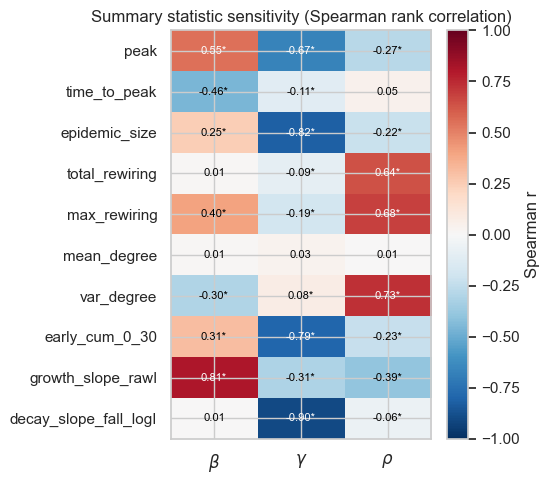


Note: mean_degree (row 5) has |r| < 0.05 for all parameters — excluded from distance.


In [121]:
PARAM_NAMES = ["beta", "gamma", "rho"]
n_stats  = len(SUMMARY_NAMES)
n_params = len(PARAM_NAMES)

corr_mat = np.zeros((n_stats, n_params))
pval_mat = np.zeros((n_stats, n_params))

for i in range(n_stats):
    for j in range(n_params):
        r, p = spearmanr(sims_prior[:, i], params_prior[:, j])
        corr_mat[i, j] = r
        pval_mat[i, j] = p

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(n_params))
ax.set_xticklabels([r"$\beta$", r"$\gamma$", r"$\rho$"], fontsize=12)
ax.set_yticks(range(n_stats))
ax.set_yticklabels(SUMMARY_NAMES)
plt.colorbar(im, ax=ax, label="Spearman r")
ax.set_title("Summary statistic sensitivity (Spearman rank correlation)")

for i in range(n_stats):
    for j in range(n_params):
        star = "*" if pval_mat[i, j] < 0.001 else ""
        col  = "white" if abs(corr_mat[i, j]) > 0.5 else "black"
        ax.text(j, i, f"{corr_mat[i,j]:.2f}{star}", ha="center", va="center",
                fontsize=8, color=col)

plt.tight_layout()
plt.show()

print("\nNote: mean_degree (row 5) has |r| < 0.05 for all parameters — excluded from distance.")


### 5.1 Candidate statistic subsets (before final selection)

We first define only the fixed candidate sets (A-D).
The final chosen subset is defined later, after inspecting the selection curve in Section 6.2.

| Set | Indices | What it emphasizes |
|-----|---------|--------------------|
| A | 0, 1, 2 | Infected fraction only |
| B | 0, 1, 2, 3, 4 | + rewiring totals/peaks |
| C | 0, 1, 2, 3, 4, 6 | + degree variance |
| D | 0, 1, 2, 7, 8, 9 | + growth and decay slopes |

`mean_degree` (index 5) is excluded from distances.

In [138]:
BASE_SUBSETS = {
    "Set A: infected only": [0, 1, 2],
    "Set B: + rewiring": [0, 1, 2, 3, 4],
    "Set C: + degree variance": [0, 1, 2, 3, 4, 6],
    "Set D: + growth/decay slopes": [0, 1, 2, 7, 8, 9],
}

# Final SUBSETS is defined later after manual curve-based selection in Section 6.2.

## 6. Rejection ABC

### 6.1 Algorithm

```
while n_accepted < n_target:
    theta ~ Uniform(prior)
    x     ~ simulator(theta)
    s     = calc_summaries(x)
    d     = ||norm(s) - norm(s_obs)||_2
    if d <= epsilon:
        accept theta
```

We implement this as a **distance-threshold** version: run all prior simulations upfront
(already done above), then accept the top $\alpha = 5\%$ by distance.  This is equivalent
to the while-loop above and is much faster for a fixed prior sample.

In [139]:
def calc_distance(s_sim_norm, s_target_norm, stat_indices):
    """Euclidean distance between normalised summary vectors for a given subset."""
    diff = s_sim_norm[:, stat_indices] - s_target_norm[stat_indices]
    return np.linalg.norm(diff, axis=1)


def abc_rejection(s_target_norm, sims_norm, params, stat_indices, acceptance_rate=0.05):
    """
    Rejection ABC using a subset of summary statistics.

    Parameters
    ----------
    s_target_norm    : normalised observed summary vector, shape (K,)
    sims_norm        : normalised simulated summaries, shape (N, K)
    params           : simulated parameters, shape (N, 3)
    stat_indices     : list of statistic indices to include in distance
    acceptance_rate  : top fraction to accept (default 5 %)

    Returns
    -------
    accepted_params  : shape (n_accepted, 3)   [beta, gamma, rho]
    threshold        : distance threshold used
    """
    distances  = calc_distance(sims_norm, s_target_norm, stat_indices)
    n_accept   = max(1, int(acceptance_rate * len(params)))
    threshold  = np.sort(distances)[n_accept]
    accepted   = params[distances <= threshold]
    return accepted, threshold


### 6.2 Pseudo-observed validation

Before applying ABC to the real (unknown) data, we validate the pipeline on a **pseudo-observed**
dataset generated with *known* parameters.  This is the standard sanity check recommended by
Nunes & Balding (2010): if the posterior mean does not recover the true values, something is
wrong with the statistics, distance, or normalisation.

We use $(\beta, \gamma, \rho) = (0.20, 0.10, 0.40)$ and $R = 40$ replicates to match the
structure of the real observed data.

In [140]:
TRUE_BETA, TRUE_GAMMA, TRUE_RHO = 0.20, 0.10, 0.40
R_PSEUDO = 40

rng_pseudo = np.random.default_rng(99)
pseudo_reps = [
    calc_summaries(*simulate(beta=TRUE_BETA, gamma=TRUE_GAMMA, rho=TRUE_RHO, rng=rng_pseudo))
    for _ in range(R_PSEUDO)
]
s_pseudo      = np.mean(pseudo_reps, axis=0)
s_pseudo_norm = s_pseudo / s_std

print(f"True parameters: β={TRUE_BETA}, γ={TRUE_GAMMA}, ρ={TRUE_RHO}")
print(f"Pseudo-observed summary (normalised): {s_pseudo_norm.round(3)}")


True parameters: β=0.2, γ=0.1, ρ=0.4
Pseudo-observed summary (normalised): [ 2.46   1.595  0.946  1.785  1.921 33.23   3.314  1.666  1.237 -0.426]


In [141]:
pseudo_results = {}
header = f"{'Subset':<30} {'E[β]':>7} {'E[γ]':>7} {'E[ρ]':>7}  {'std(β)':>7} {'std(γ)':>7} {'std(ρ)':>7}  {'RSSE':>7}  n"
print("=== Pseudo-observed validation (base sets A-D, N=5000, α=5%) ===\n")
print(header)
print("-" * len(header))

for label, idx in BASE_SUBSETS.items():
    acc, eps = abc_rejection(s_pseudo_norm, sims_norm, params_prior, idx, acceptance_rate=0.05)
    pseudo_results[label] = acc
    m  = acc.mean(axis=0)
    sd = acc.std(axis=0)
    rsse = np.sqrt(((m - np.array([TRUE_BETA, TRUE_GAMMA, TRUE_RHO])) ** 2).sum())
    print(f"{label:<30} {m[0]:>7.3f} {m[1]:>7.3f} {m[2]:>7.3f}  {sd[0]:>7.3f} {sd[1]:>7.3f} {sd[2]:>7.3f}  {rsse:>7.4f}  {len(acc)}")


=== Pseudo-observed validation (base sets A-D, N=5000, α=5%) ===

Subset                            E[β]    E[γ]    E[ρ]   std(β)  std(γ)  std(ρ)     RSSE  n
-------------------------------------------------------------------------------------------
Set A: infected only             0.236   0.103   0.425    0.080   0.018   0.242   0.0440  251
Set B: + rewiring                0.253   0.119   0.443    0.072   0.032   0.090   0.0708  251
Set C: + degree variance         0.255   0.121   0.439    0.076   0.034   0.088   0.0705  251
Set D: + growth/decay slopes     0.238   0.101   0.440    0.083   0.016   0.235   0.0556  251


In [142]:
# Minimal automatic statistic selection (forward search on pseudo-observed targets)
rng_sel = np.random.default_rng(2026)
prior_std_sel = params_prior.std(axis=0)
candidate_idx = [i for i, n in enumerate(SUMMARY_NAMES) if n != "mean_degree"]  # keep prior exclusion

# Build pseudo-observed targets from random prior draws (fast, objective)
M_TARGETS = 20
target_thetas = np.column_stack([
    rng_sel.uniform(0.05, 0.50, M_TARGETS),
    rng_sel.uniform(0.02, 0.20, M_TARGETS),
    rng_sel.uniform(0.00, 0.80, M_TARGETS),
])
target_summ_norm = np.array([
    calc_summaries(*simulate(beta=b, gamma=g, rho=r, rng=rng_sel)) / s_std
    for b, g, r in target_thetas
])

def subset_score(idx, alpha=0.05):
    """Lower is better: normalized RMSE of posterior mean over pseudo targets."""
    se = []
    for s_t, theta_true in zip(target_summ_norm, target_thetas):
        acc, _ = abc_rejection(s_t, sims_norm, params_prior, idx, acceptance_rate=alpha)
        theta_hat = acc.mean(axis=0)
        se.append(((theta_hat - theta_true) / prior_std_sel) ** 2)
    return np.sqrt(np.mean(se, axis=0).sum())

# Greedy forward selection: simple, strong baseline, easy to explain in report
selected = []
remaining = candidate_idx.copy()
rows = []
max_k = min(6, len(candidate_idx))

for step in range(max_k):
    trials = []
    for j in remaining:
        idx = sorted(selected + [j])
        trials.append((subset_score(idx), j, idx))
    best_score, best_j, best_idx = min(trials, key=lambda x: x[0])
    selected = best_idx
    remaining.remove(best_j)
    rows.append({
        "k": len(selected),
        "score_nrmse": best_score,
        "subset_idx": selected.copy(),
        "subset_names": [SUMMARY_NAMES[i] for i in selected],
    })

selection_table = pd.DataFrame(rows)
best_row = selection_table.loc[selection_table["score_nrmse"].idxmin()]
BEST_STAT_IDX = best_row["subset_idx"]

print("=== Automatic Summary-Stat Selection (Pseudo-Observed CV) ===")
display(selection_table[["k", "score_nrmse", "subset_names"]])
print(f"\nSelected best subset (k={len(BEST_STAT_IDX)}): {BEST_STAT_IDX}")
print("Names:", [SUMMARY_NAMES[i] for i in BEST_STAT_IDX])

=== Automatic Summary-Stat Selection (Pseudo-Observed CV) ===


,k,score_nrmse,subset_names
0,1,1.104607,[epidemic_size]
1,2,0.862453,"[epidemic_size, max_rewiring]"
2,3,0.603252,"[epidemic_size, max_rewiring, growth_slope_rawI]"
3,4,0.516467,"[epidemic_size, max_rewiring, early_cum_0_30, ..."
4,5,0.511549,"[epidemic_size, total_rewiring, max_rewiring, ..."
5,6,0.518034,"[peak, epidemic_size, total_rewiring, max_rewi..."



Selected best subset (k=5): [2, 3, 4, 7, 8]
Names: ['epidemic_size', 'total_rewiring', 'max_rewiring', 'early_cum_0_30', 'growth_slope_rawI']


### 6.2.1 Manual subset decision from the selection curve

Use the curve below to choose $k$ manually (elbow-style).
Then set `MANUAL_SELECTED_K` and the notebook will build the final `SUBSETS` dictionary for all downstream analyses.

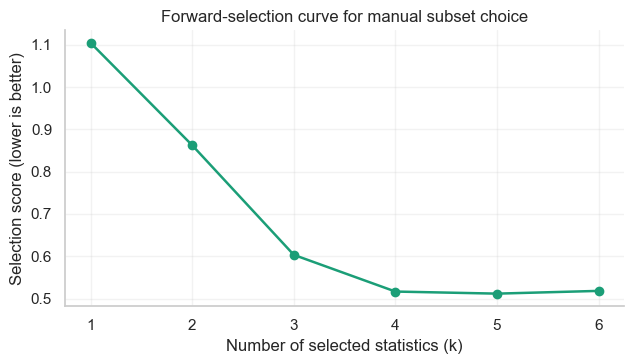

Manual choice: k=5
Chosen indices: [2, 3, 4, 7, 8]
Chosen names: ['epidemic_size', 'total_rewiring', 'max_rewiring', 'early_cum_0_30', 'growth_slope_rawI']

Final subsets for downstream analysis:
  Set A: infected only           [0, 1, 2]
  Set B: + rewiring              [0, 1, 2, 3, 4]
  Set C: + degree variance       [0, 1, 2, 3, 4, 6]
  Set D: + growth/decay slopes   [0, 1, 2, 7, 8, 9]
  Manual-selected subset         [2, 3, 4, 7, 8]


In [161]:
# Manual decision aid: pick k from the forward-selection curve
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(selection_table["k"], selection_table["score_nrmse"], marker="o", lw=1.8, color=PALETTE[0])
ax.set_xlabel("Number of selected statistics (k)")
ax.set_ylabel("Selection score (lower is better)")
ax.set_title("Forward-selection curve for manual subset choice")
ax.grid(alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# ---- Manual choice (edit this) ----
MANUAL_SELECTED_K = 5

if MANUAL_SELECTED_K not in set(selection_table["k"].tolist()):
    raise ValueError(f"MANUAL_SELECTED_K={MANUAL_SELECTED_K} is not available in selection_table")

manual_row = selection_table.loc[selection_table["k"] == MANUAL_SELECTED_K].iloc[0]
MANUAL_SELECTED_IDX = list(manual_row["subset_idx"])
MANUAL_SELECTED_NAMES = [SUMMARY_NAMES[i] for i in MANUAL_SELECTED_IDX]
SELECTED_SUBSET_LABEL = "Manual-selected subset"

print(f"Manual choice: k={MANUAL_SELECTED_K}")
print("Chosen indices:", MANUAL_SELECTED_IDX)
print("Chosen names:", MANUAL_SELECTED_NAMES)

# Final subsets used downstream (defined only after manual decision)
SUBSETS = {
    **BASE_SUBSETS,
    SELECTED_SUBSET_LABEL: MANUAL_SELECTED_IDX,
}

print("\nFinal subsets for downstream analysis:")
for name, idx in SUBSETS.items():
    print(f"  {name:<30} {idx}")

### 6.3 Rejection ABC on real observed data

In [162]:
real_results = {}
header = f"{'Subset':<30} {'E[β]':>7} {'E[γ]':>7} {'E[ρ]':>7}  {'std(β)':>7} {'std(γ)':>7} {'std(ρ)':>7}  n"
print("=== Real observed data (N=5000, α=5%) ===\n")
print(header)
print("-" * len(header))

for label, idx in SUBSETS.items():
    acc, eps = abc_rejection(s_obs_norm, sims_norm, params_prior, idx, acceptance_rate=0.05)
    real_results[label] = acc
    m  = acc.mean(axis=0)
    sd = acc.std(axis=0)
    print(f"{label:<30} {m[0]:>7.3f} {m[1]:>7.3f} {m[2]:>7.3f}  {sd[0]:>7.3f} {sd[1]:>7.3f} {sd[2]:>7.3f}  {len(acc)}")


=== Real observed data (N=5000, α=5%) ===

Subset                            E[β]    E[γ]    E[ρ]   std(β)  std(γ)  std(ρ)  n
----------------------------------------------------------------------------------
Set A: infected only             0.212   0.088   0.413    0.071   0.014   0.234  251
Set B: + rewiring                0.196   0.097   0.333    0.054   0.026   0.083  251
Set C: + degree variance         0.202   0.101   0.332    0.060   0.029   0.079  251
Set D: + growth/decay slopes     0.211   0.086   0.419    0.073   0.013   0.234  251
Manual-selected subset           0.187   0.093   0.322    0.056   0.020   0.087  251


## 7. Quantifying Statistic Quality on Real Data

On pseudo-observed data we have ground truth (RSSE). On real data we don't. The two
principled alternatives are:

**1. Posterior contraction ratio** (Schmon et al. 2021, Fearnhead & Prangle 2012):

$$c_j = 1 - \frac{\text{std}(\theta_j \mid y_{\text{obs}})}{\text{std}(\theta_j \sim \text{prior})}$$

$c_j = 0$ means the posterior did not update from the prior (statistic uninformative).
$c_j = 1$ means the posterior collapses to a point (perfect identification).

**2. Approximate KL divergence** (entropy reduction) from prior to posterior, estimated
from samples via:

$$\widehat{\mathrm{KL}}(q \| p) \approx \log\left(\frac{n_{\text{prior}}}{n_{\text{posterior}} - 1}\right) + \frac{d}{n} \sum_i \log \nu_k(\theta_i^{\text{post}})$$

where $\nu_k$ is the distance to the $k$-th nearest neighbour in the prior sample (Pérez-Cruz 2008).
This is expensive for high dimensions; for 3 parameters and 5000 prior draws the simple
ratio estimator below is sufficient.

For a report-grade analysis, contraction ratios are the right thing to put in a table.
The key reference is Frazier et al. (2018) "Asymptotic Properties of ABC" — they prove
that well-chosen sufficient statistics produce contraction at rate $n^{-1/2}$.

In [163]:
PRIOR_STD = np.array([
    np.std(params_prior[:, 0]),   # beta
    np.std(params_prior[:, 1]),   # gamma
    np.std(params_prior[:, 2]),   # rho
])

PRIOR_BOUNDS = [(0.05, 0.50), (0.02, 0.20), (0.00, 0.80)]
PARAM_LABELS = [r"$\beta$", r"$\gamma$", r"$\rho$"]

print("=== Posterior Contraction Ratios (real data) ===\n")
print(f"{'Subset':<30} {'c(β)':>7} {'c(γ)':>7} {'c(ρ)':>7}   {'std(β)':>7} {'std(γ)':>7} {'std(ρ)':>7}")
print(f"{'Prior std':<30} {'':>7} {'':>7} {'':>7}   {PRIOR_STD[0]:>7.3f} {PRIOR_STD[1]:>7.3f} {PRIOR_STD[2]:>7.3f}")
print("-" * 75)

contraction = {}
for label, accepted in real_results.items():
    post_std = accepted.std(axis=0)
    c = 1 - post_std / PRIOR_STD
    contraction[label] = c
    print(f"{label:<30} {c[0]:>7.3f} {c[1]:>7.3f} {c[2]:>7.3f}   {post_std[0]:>7.3f} {post_std[1]:>7.3f} {post_std[2]:>7.3f}")

print("\nInterpretation: c ≈ 0 → posterior ≈ prior (uninformative). c → 1 → tight posterior.")
print("Compare contraction patterns together with RSSE and confounding diagnostics from Section 9.")


=== Posterior Contraction Ratios (real data) ===

Subset                            c(β)    c(γ)    c(ρ)    std(β)  std(γ)  std(ρ)
Prior std                                                  0.129   0.052   0.231
---------------------------------------------------------------------------
Set A: infected only             0.454   0.728  -0.013     0.071   0.014   0.234
Set B: + rewiring                0.586   0.500   0.642     0.054   0.026   0.083
Set C: + degree variance         0.534   0.451   0.657     0.060   0.029   0.079
Set D: + growth/decay slopes     0.435   0.743  -0.010     0.073   0.013   0.234
Manual-selected subset           0.571   0.611   0.626     0.056   0.020   0.087

Interpretation: c ≈ 0 → posterior ≈ prior (uninformative). c → 1 → tight posterior.
Compare contraction patterns together with RSSE and confounding diagnostics from Section 9.


### 7.1 Contraction ratio visualisation

This figure compares contraction across all candidate summary-statistic subsets.

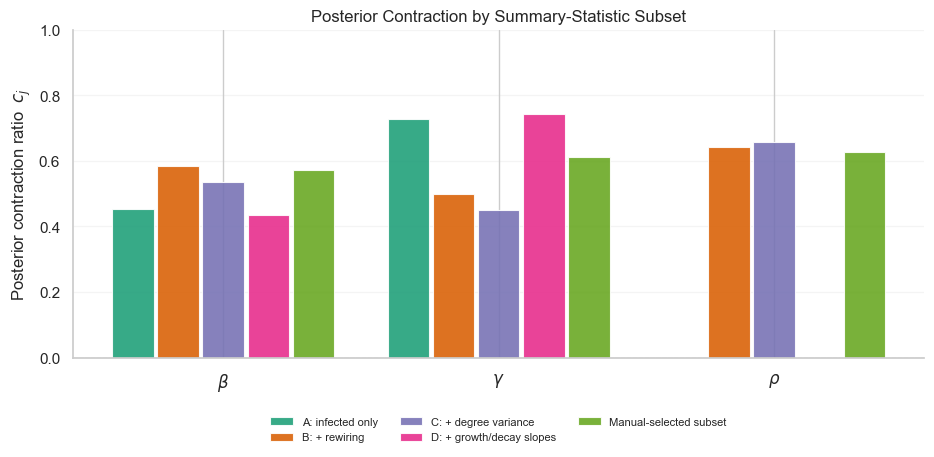

In [164]:
param_names_str = [r"$\beta$", r"$\gamma$", r"$\rho$"]
subset_labels = list(contraction.keys())
n_subsets = len(subset_labels)

x = np.arange(len(param_names_str), dtype=float)
group_width = 0.82
width = group_width / max(n_subsets, 1)
offsets = (np.arange(n_subsets) - (n_subsets - 1) / 2.0) * width

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for i, label in enumerate(subset_labels):
    c = contraction[label]
    color = PALETTE[i % len(PALETTE)]
    ax.bar(
        x + offsets[i], c, width=width * 0.92,
        label=label.replace("Set ", "").replace("Auto-selected subset", "Auto"),
        color=color, alpha=0.88, edgecolor="white", linewidth=0.8
    )

ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(param_names_str, fontsize=12)
ax.set_ylabel("Posterior contraction ratio  $c_j$")
ax.set_title("Posterior Contraction by Summary-Statistic Subset")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.20)
ax.legend(
    fontsize=8, ncol=min(3, n_subsets),
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15)
)

sns.despine()
plt.tight_layout()
plt.show()

## 8. Posterior Visualisations

### 8.1 Prior vs. posterior marginal histograms

If the posterior histogram is flat and matches the prior, the statistics chosen carry no
information about that parameter.  A concentrated, shifted histogram indicates successful
inference.

We use `seaborn.kdeplot` for the posterior (smooth density) and draw the uniform prior as
a flat reference line bounded by the prior support.

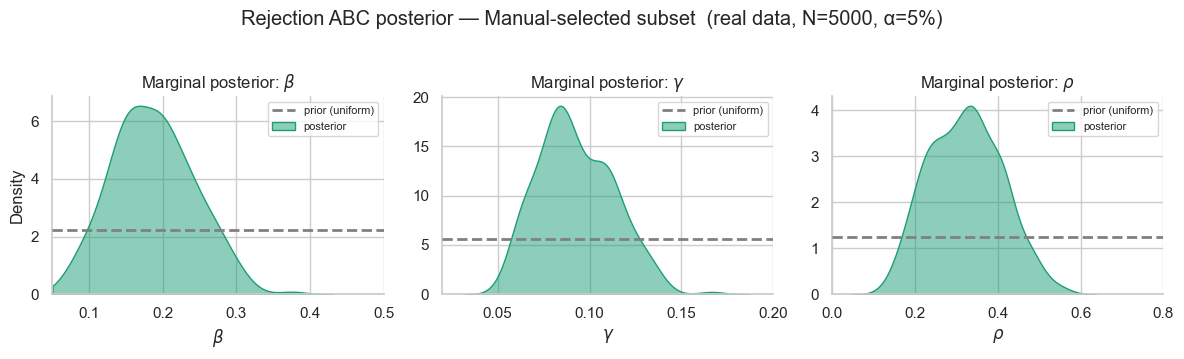

In [170]:
accepted_auto = real_results[SELECTED_SUBSET_LABEL]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for j, (ax, label, bounds) in enumerate(zip(axes, PARAM_LABELS, PRIOR_BOUNDS)):
    # prior as a uniform reference line
    prior_height = 1.0 / (bounds[1] - bounds[0])
    ax.hlines(prior_height, bounds[0], bounds[1], colors="grey", lw=2,
                linestyles="--", label="prior (uniform)", zorder=3)
    # posterior KDE (seaborn)
    sns.kdeplot(accepted_auto[:, j], ax=ax, color=PALETTE[0], fill=True,
                alpha=0.5, label="posterior", clip=bounds)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("Density" if j == 0 else "")
    ax.set_xlim(bounds)
    ax.set_title(f"Marginal posterior: {label}")
    ax.legend(fontsize=8)

plt.suptitle(f"Rejection ABC posterior — {SELECTED_SUBSET_LABEL}  (real data, N=5000, α=5%)", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


### 8.2 Pairwise joint posteriors

Scatter plots reveal correlations between parameters. The β–ρ plane is the most
important diagnostic: if β and ρ are not jointly identified, the posterior cloud will
be elongated along the anti-diagonal (high β compensated by high ρ, or vice versa).

With the manual subset now chosen, this plot shows the contrast between Set A and the
selected subset directly.

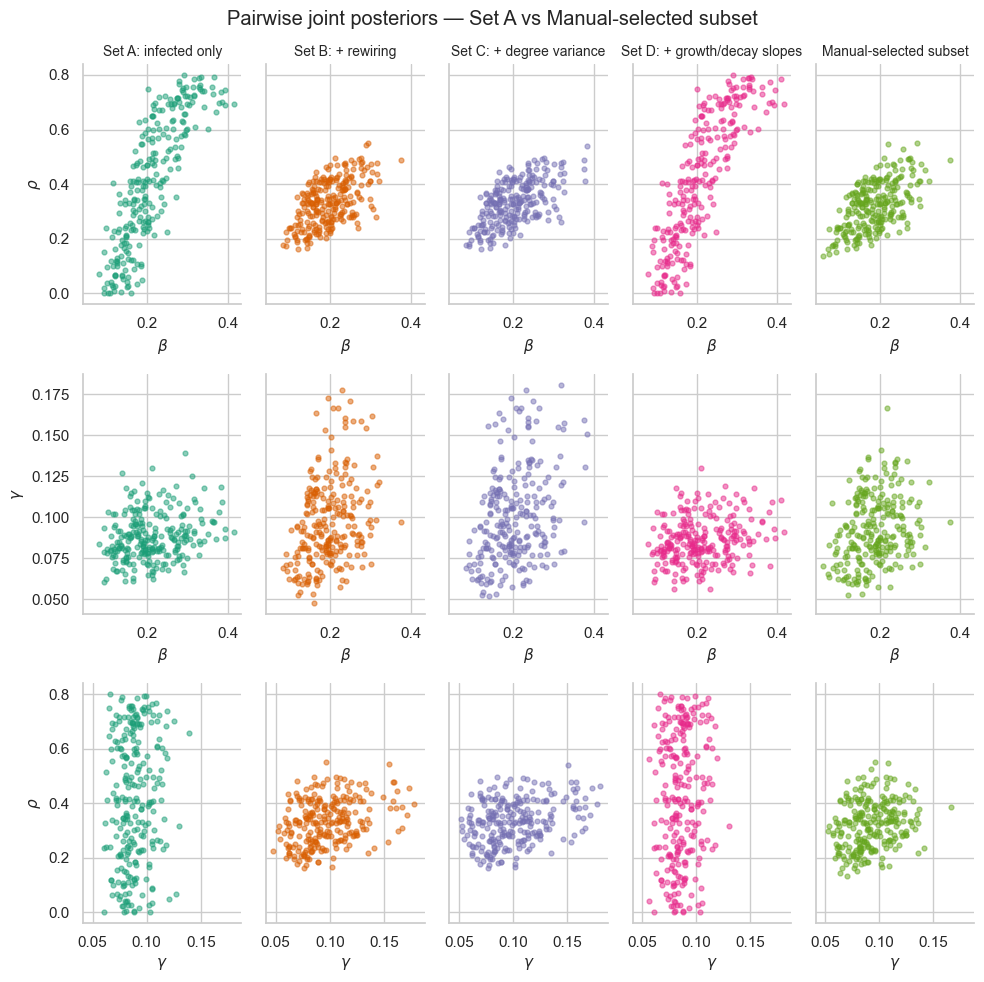

In [171]:
import seaborn as sns

pairs = [(0, 2, r"$\beta$", r"$\rho$"),
        (0, 1, r"$\beta$", r"$\gamma$"),
        (1, 2, r"$\gamma$", r"$\rho$")]

fig, axes = plt.subplots(3, len(real_results), figsize=(10, 10), 
                            sharey='row', sharex='row')

for row, (xi, yi, xl, yl) in enumerate(pairs):
    for col, (label, accepted) in enumerate(real_results.items()):
        ax = axes[row, col]
        ax.scatter(accepted[:, xi], accepted[:, yi], s=12, alpha=0.5, 
                    color=PALETTE[col % len(PALETTE)])
        ax.set_xlabel(xl, fontsize=11)
        if col == 0:
            ax.set_ylabel(yl, fontsize=11)
        if row == 0:
            ax.set_title(label, fontsize=10)

plt.suptitle(f"Pairwise joint posteriors — Set A vs {SELECTED_SUBSET_LABEL}", y=0.98)
sns.despine()
plt.tight_layout()
plt.show()

### 8.3 New infections curve (incidence)

The raw simulator output is *prevalence* $I(t)/N$, not incidence.  We compute
**new infections** at each step as the first difference of $I(t)$, clipped at zero
(so negative spikes from recoveries do not appear as negative incidence).

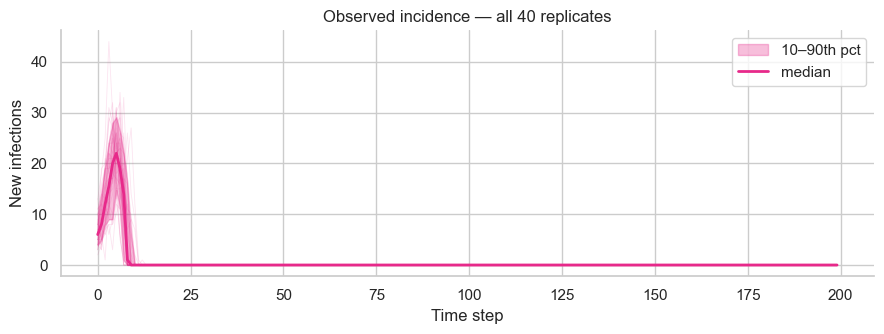

In [168]:
def prevalence_to_incidence(infected_fraction, N=200):
    """Approximate new infections at each step = max(ΔI, 0) * N."""
    delta = np.diff(infected_fraction)   # length T
    return np.clip(delta, 0, None) * N

# Observed incidence: one row per replicate
inf_wide_arr  = inf_wide.values                          # (201, 40)
obs_incidence = np.array([prevalence_to_incidence(inf_wide_arr[:, r])
                           for r in range(inf_wide_arr.shape[1])])   # (40, 200)

inc_lo  = np.quantile(obs_incidence, 0.10, axis=0)
inc_med = np.quantile(obs_incidence, 0.50, axis=0)
inc_hi  = np.quantile(obs_incidence, 0.90, axis=0)
t_inc   = np.arange(200)

fig, ax = plt.subplots(figsize=(9, 3.5))
for row in obs_incidence:
    ax.plot(t_inc, row, color=PALETTE[3], alpha=0.12, lw=0.6)
ax.fill_between(t_inc, inc_lo, inc_hi, color=PALETTE[3], alpha=0.30, label="10–90th pct")
ax.plot(t_inc, inc_med, color=PALETTE[3], lw=2, label="median")
ax.set(xlabel="Time step", ylabel="New infections", title="Observed incidence — all 40 replicates")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


### 8.4 Posterior predictive check (incidence)

This is the most important validation step. We randomly select 50 accepted parameter sets
from the auto-selected subset posterior and re-run the simulator for each. If the model is
well calibrated, the observed incidence curve should lie within the cloud of simulated curves.

This is the same diagnostic used by the Epydemix tutorial (`plot_quantiles`)
and by Minter & Retkute (2019) — plotting a grey envelope of posterior-predictive trajectories
against the bold observed curve.

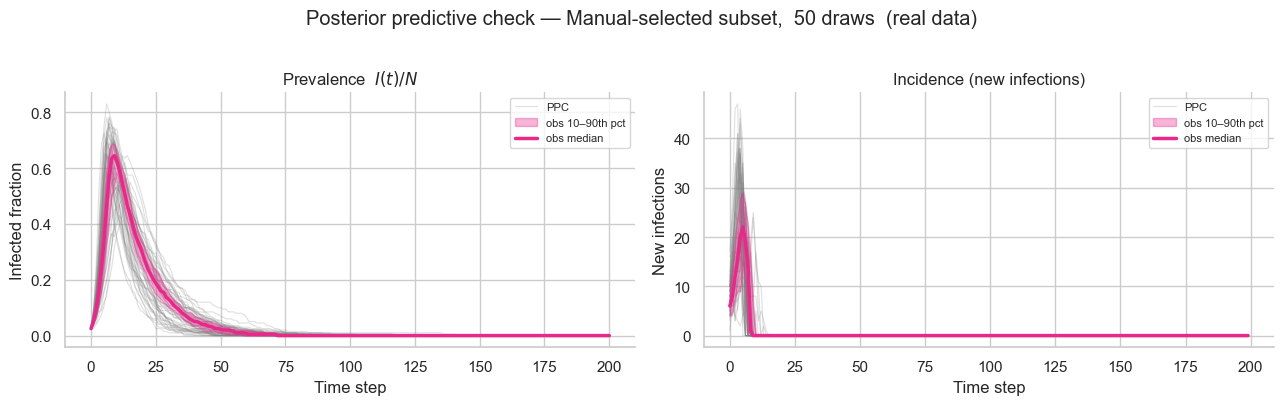

In [172]:
N_PPC    = 50
rng_ppc  = np.random.default_rng(123)
accepted_auto = real_results[SELECTED_SUBSET_LABEL]
ppc_idx  = rng_ppc.choice(len(accepted_auto), size=N_PPC, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax_idx, (ax, title, transform) in enumerate(zip(
    axes,
    ["Prevalence  $I(t)/N$", "Incidence (new infections)"],
    [lambda x: x, prevalence_to_incidence]
)):
    # Grey posterior-predictive trajectories
    for k, pid in enumerate(ppc_idx):
        beta_k, gamma_k, rho_k = accepted_auto[pid]
        inf_k, _, _ = simulate(beta=beta_k, gamma=gamma_k, rho=rho_k, rng=rng_ppc)
        y = transform(inf_k)
        ax.plot(np.arange(len(y)), y, color="grey", alpha=0.25, lw=0.8,
                label="PPC" if k == 0 else None)

    # Bold observed: percentile band + median
    if ax_idx == 0:
        lo  = inf_lo.values
        med = inf_med.values
        hi  = inf_hi.values
        t_obs = inf_wide.index.values
    else:
        lo, med, hi = inc_lo, inc_med, inc_hi
        t_obs = t_inc

    ax.fill_between(t_obs, lo, hi, color=PALETTE[3], alpha=0.35, zorder=4,
                    label="obs 10–90th pct")
    ax.plot(t_obs, med, color=PALETTE[3], lw=2.5, label="obs median", zorder=5)
    ax.set(xlabel="Time step", title=title)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Infected fraction")
axes[1].set_ylabel("New infections")
plt.suptitle(f"Posterior predictive check — {SELECTED_SUBSET_LABEL},  {N_PPC} draws  (real data)", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()


### 8.5 Degree distribution: posterior predictive vs. observed

For the adaptive model, the final degree histogram is specifically sensitive to $\rho$.
We compare the observed distribution (in bold) against the posterior-predictive
degree histograms (grey), to verify that the inferred $\rho$ correctly reproduces the
network structure at $t = T$.

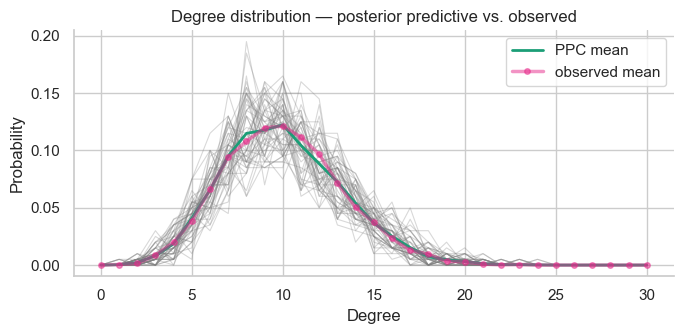

In [173]:
ppc_deg_stack = []
for pid in ppc_idx:
    beta_k, gamma_k, rho_k = accepted_auto[pid]
    _, _, deg_k = simulate(beta=beta_k, gamma=gamma_k, rho=rho_k, rng=rng_ppc)
    ppc_deg_stack.append(deg_k / deg_k.sum())
ppc_deg_stack = np.array(ppc_deg_stack)   # (N_PPC, 31)

degrees = np.arange(31)
fig, ax = plt.subplots(figsize=(7, 3.5))

for row in ppc_deg_stack:
    ax.plot(degrees, row, color="grey", alpha=0.3, lw=0.8)
ax.plot(degrees, ppc_deg_stack.mean(axis=0), color=PALETTE[0], lw=2, label="PPC mean")
ax.plot(degrees, obs_deg_prob.values, color=PALETTE[3], lw=2.5, marker="o", ms=4,
        alpha=0.5, label="observed mean", zorder=5)

ax.set(xlabel="Degree", ylabel="Probability",
        title="Degree distribution — posterior predictive vs. observed")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()


=== Evidence table (alpha=5%) ===


,eps_real,rsse_pseudo,E[beta],E[gamma],E[rho],std(beta),std(gamma),std(rho),c(beta),c(gamma),c(rho),"corr(beta,rho)","abs_corr(beta,rho)"
subset,,,,,,,,,,,,,
Set A: infected only,0.4914,0.0440,0.2115,0.0884,0.4131,0.0706,0.0142,0.2344,0.4538,0.7278,-0.0126,0.8337,0.8337
Set B: + rewiring,0.9637,0.0708,0.1961,0.0971,0.3333,0.0536,0.0261,0.0828,0.5857,0.5003,0.6421,0.5562,0.5562
Set C: + degree variance,1.0463,0.0705,0.2017,0.1006,0.3324,0.0602,0.0287,0.0793,0.5343,0.4508,0.6573,0.5981,0.5981
Set D: + growth/decay slopes,0.6908,0.0556,0.2115,0.0860,0.4189,0.0731,0.0134,0.2339,0.4347,0.7425,-0.0105,0.8412,0.8412
Auto-selected subset,1.0443,0.0549,0.1868,0.0925,0.3217,0.0555,0.0203,0.0866,0.5708,0.6105,0.6259,0.5816,0.5816


=== Multi-target pseudo validation (27 targets) ===


,mean_rsse_multi,std_rsse_multi
subset,,
Auto-selected subset,0.0551,0.0178
Set B: + rewiring,0.0678,0.0142
Set C: + degree variance,0.0710,0.0141
Set A: infected only,0.0853,0.0391
Set D: + growth/decay slopes,0.0881,0.0424


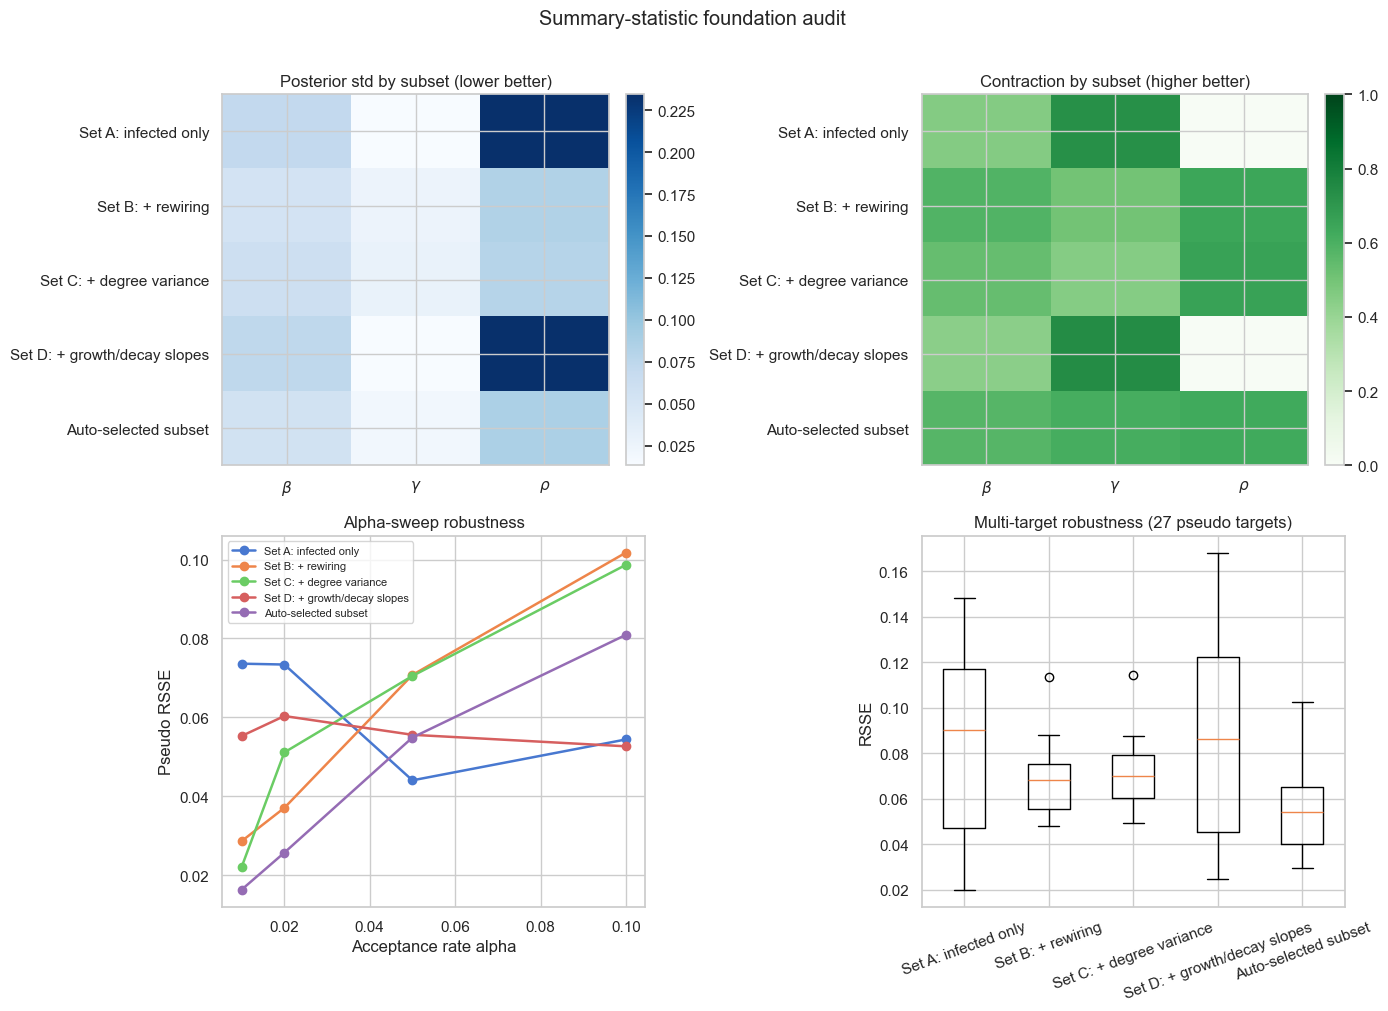

=== Composite rank (lower score is better) ===


,rsse_pseudo,std(beta),std(gamma),std(rho),"abs_corr(beta,rho)",mean_rsse_multi,score
subset,,,,,,,
Set B: + rewiring,0.0708,0.0536,0.0261,0.0828,0.5562,0.0678,10.0
Auto-selected subset,0.0549,0.0555,0.0203,0.0866,0.5816,0.0551,11.0
Set C: + degree variance,0.0705,0.0602,0.0287,0.0793,0.5981,0.0710,15.0
Set A: infected only,0.0440,0.0706,0.0142,0.2344,0.8337,0.0853,19.0
Set D: + growth/decay slopes,0.0556,0.0731,0.0134,0.2339,0.8412,0.0881,20.0


In [ ]:
# Robust evidence audit for summary-stat choices
true_theta = np.array([TRUE_BETA, TRUE_GAMMA, TRUE_RHO], dtype=float)

# 1) Core evidence table at alpha=5%
rows = []
for label, idx in SUBSETS.items():
    acc_pseudo, _ = abc_rejection(s_pseudo_norm, sims_norm, params_prior, idx, acceptance_rate=0.05)
    m_pseudo = acc_pseudo.mean(axis=0)
    rsse = float(np.sqrt(np.sum((m_pseudo - true_theta) ** 2)))

    acc_real, eps_real = abc_rejection(s_obs_norm, sims_norm, params_prior, idx, acceptance_rate=0.05)
    m_real = acc_real.mean(axis=0)
    sd_real = acc_real.std(axis=0)
    c_real = 1.0 - sd_real / PRIOR_STD
    corr_br = float(np.corrcoef(acc_real[:, 0], acc_real[:, 2])[0, 1])

    rows.append({
        "subset": label,
        "eps_real": float(eps_real),
        "rsse_pseudo": rsse,
        "E[beta]": float(m_real[0]),
        "E[gamma]": float(m_real[1]),
        "E[rho]": float(m_real[2]),
        "std(beta)": float(sd_real[0]),
        "std(gamma)": float(sd_real[1]),
        "std(rho)": float(sd_real[2]),
        "c(beta)": float(c_real[0]),
        "c(gamma)": float(c_real[1]),
        "c(rho)": float(c_real[2]),
        "corr(beta,rho)": corr_br,
        "abs_corr(beta,rho)": abs(corr_br),
    })

evidence_df = pd.DataFrame(rows).set_index("subset")

print("=== Evidence table (alpha=5%) ===")
display(evidence_df.round(4))

# 2) Robustness to acceptance rate alpha
alphas = np.array([0.01, 0.02, 0.05, 0.10])
alpha_rsse = {label: [] for label in SUBSETS}
for a in alphas:
    for label, idx in SUBSETS.items():
        acc, _ = abc_rejection(s_pseudo_norm, sims_norm, params_prior, idx, acceptance_rate=float(a))
        m = acc.mean(axis=0)
        alpha_rsse[label].append(float(np.sqrt(np.sum((m - true_theta) ** 2))))

# 3) Robustness across multiple pseudo-targets in parameter space
betas = [0.15, 0.20, 0.25]
gammas = [0.08, 0.10, 0.12]
rhos = [0.30, 0.40, 0.50]
R_MULTI = 10
rng_multi = np.random.default_rng(2027)

multi_rsse = {label: [] for label in SUBSETS}
for b in betas:
    for g in gammas:
        for r in rhos:
            reps = [calc_summaries(*simulate(beta=b, gamma=g, rho=r, rng=rng_multi)) for _ in range(R_MULTI)]
            s_tar = np.mean(reps, axis=0) / s_std
            theta = np.array([b, g, r], dtype=float)
            for label, idx in SUBSETS.items():
                acc, _ = abc_rejection(s_tar, sims_norm, params_prior, idx, acceptance_rate=0.05)
                m = acc.mean(axis=0)
                multi_rsse[label].append(float(np.sqrt(np.sum((m - theta) ** 2))))

multi_summary = pd.DataFrame({
    "subset": list(SUBSETS.keys()),
    "mean_rsse_multi": [np.mean(multi_rsse[k]) for k in SUBSETS],
    "std_rsse_multi": [np.std(multi_rsse[k]) for k in SUBSETS],
}).set_index("subset").sort_values("mean_rsse_multi")

print("=== Multi-target pseudo validation (27 targets) ===")
display(multi_summary.round(4))

# 4) Visual diagnostics
subset_labels = list(evidence_df.index)
params_lbl = [r"$\beta$", r"$\gamma$", r"$\rho$"]

std_mat = evidence_df[["std(beta)", "std(gamma)", "std(rho)"]].values
con_mat = evidence_df[["c(beta)", "c(gamma)", "c(rho)"]].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

im0 = axes[0, 0].imshow(std_mat, aspect="auto", cmap="Blues")
axes[0, 0].set_xticks(range(3)); axes[0, 0].set_xticklabels(params_lbl)
axes[0, 0].set_yticks(range(len(subset_labels))); axes[0, 0].set_yticklabels(subset_labels)
axes[0, 0].set_title("Posterior std by subset (lower better)")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

im1 = axes[0, 1].imshow(con_mat, aspect="auto", cmap="Greens", vmin=0, vmax=1)
axes[0, 1].set_xticks(range(3)); axes[0, 1].set_xticklabels(params_lbl)
axes[0, 1].set_yticks(range(len(subset_labels))); axes[0, 1].set_yticklabels(subset_labels)
axes[0, 1].set_title("Contraction by subset (higher better)")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

for label in subset_labels:
    axes[1, 0].plot(alphas, alpha_rsse[label], marker="o", lw=1.8, label=label)
axes[1, 0].set_xlabel("Acceptance rate alpha")
axes[1, 0].set_ylabel("Pseudo RSSE")
axes[1, 0].set_title("Alpha-sweep robustness")
axes[1, 0].legend(fontsize=8)

box_data = [multi_rsse[label] for label in subset_labels]
axes[1, 1].boxplot(box_data, tick_labels=subset_labels, vert=True)
axes[1, 1].set_ylabel("RSSE")
axes[1, 1].set_title("Multi-target robustness (27 pseudo targets)")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.suptitle("Summary-statistic foundation audit", y=1.01)
plt.tight_layout()
plt.show()

# 5) Simple ranking for decision support
rank_df = evidence_df[["rsse_pseudo", "std(beta)", "std(gamma)", "std(rho)", "abs_corr(beta,rho)"]].copy()
rank_df["mean_rsse_multi"] = multi_summary["mean_rsse_multi"]
rank_df["score"] = (
    rank_df["mean_rsse_multi"].rank(method="min")
    + rank_df["std(beta)"].rank(method="min")
    + rank_df["std(gamma)"].rank(method="min")
    + rank_df["std(rho)"].rank(method="min")
    + rank_df["abs_corr(beta,rho)"].rank(method="min")
)

print("=== Composite rank (lower score is better) ===")
display(rank_df.sort_values("score").round(4))

## 9. Summary-Statistic Foundation: Robust Comparison

This section stress-tests summary-statistic choice against the project requirement:

1. compare multiple summary sets,
2. show posterior impact,
3. test robustness across acceptance rates,
4. test robustness across multiple pseudo-observed parameter settings.

Lower RSSE, lower posterior std, and weaker $|\mathrm{corr}(\beta,\rho)|$ are better.
Higher contraction is better.